# Task 2: Clustering

In [1]:
from scmlcourse import preprocessing
from pathlib import Path
import scanpy as sc

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
data_dir = Path("../../data").resolve()
adata = sc.read_h5ad(data_dir/"qced_data.h5ad")
adata

AnnData object with n_obs × n_vars = 211345 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)

In [3]:
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


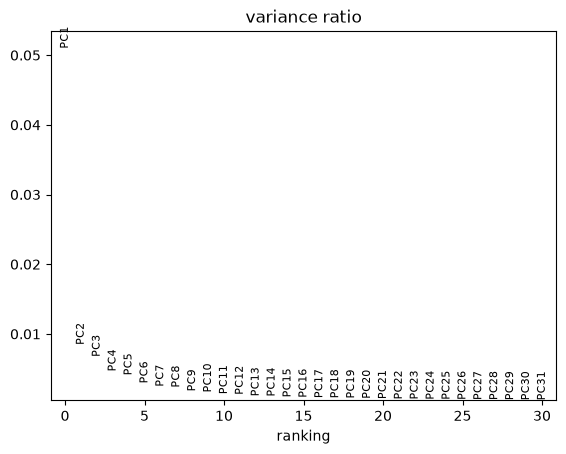

In [4]:
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata)

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


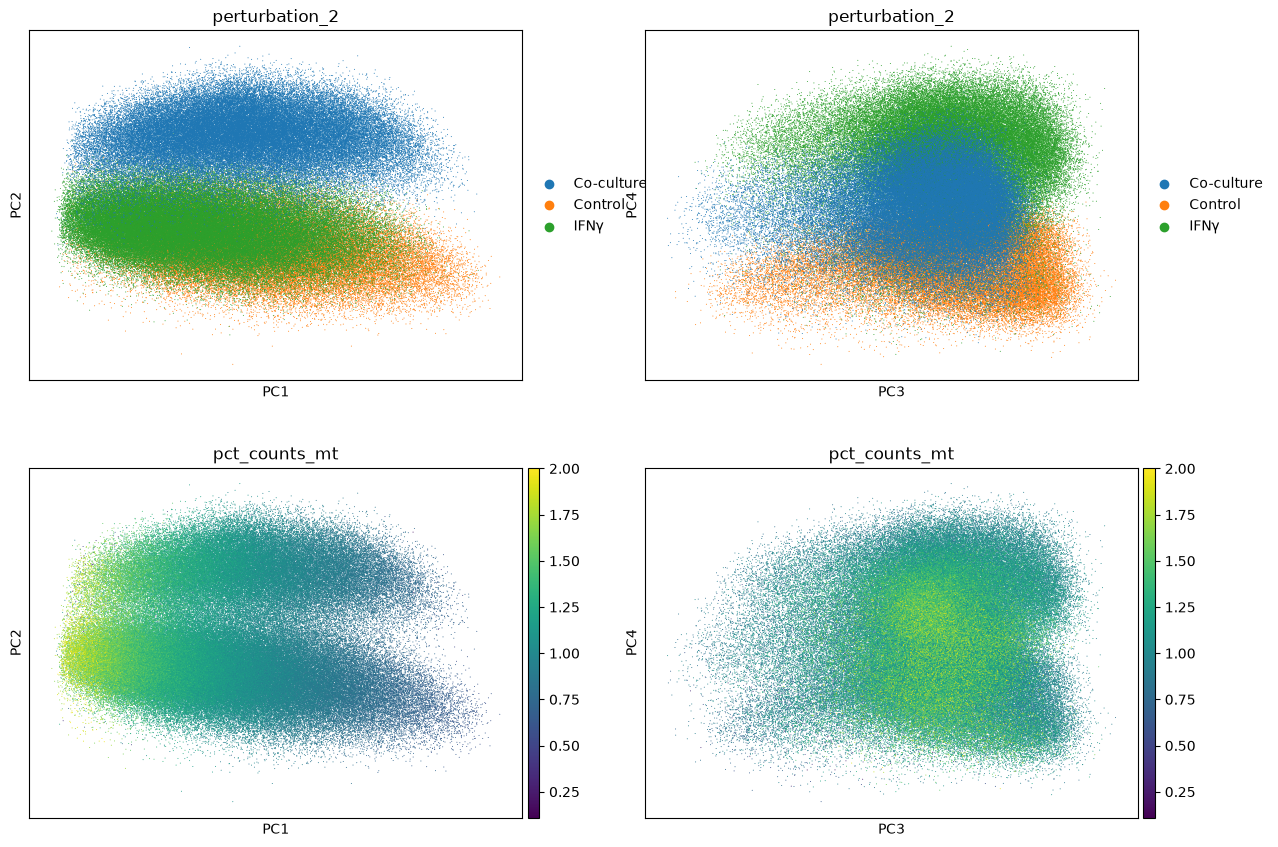

In [5]:
sc.pl.pca(
    adata,
    color=["perturbation_2","perturbation_2", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [6]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=10)
sc.tl.umap(adata)

/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
/home/ubuntu/miniforge/envs/scml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


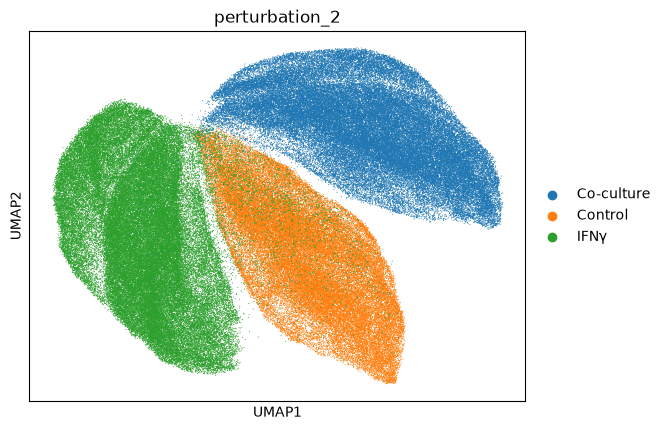

In [7]:
sc.pl.umap(
    adata,
    color="perturbation_2",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [8]:
for res in [0.2, 0.3, 0.4, 0.5, 1]:
    sc.tl.leiden(adata, flavor="igraph", resolution=res, key_added=f"leiden_{res}")

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


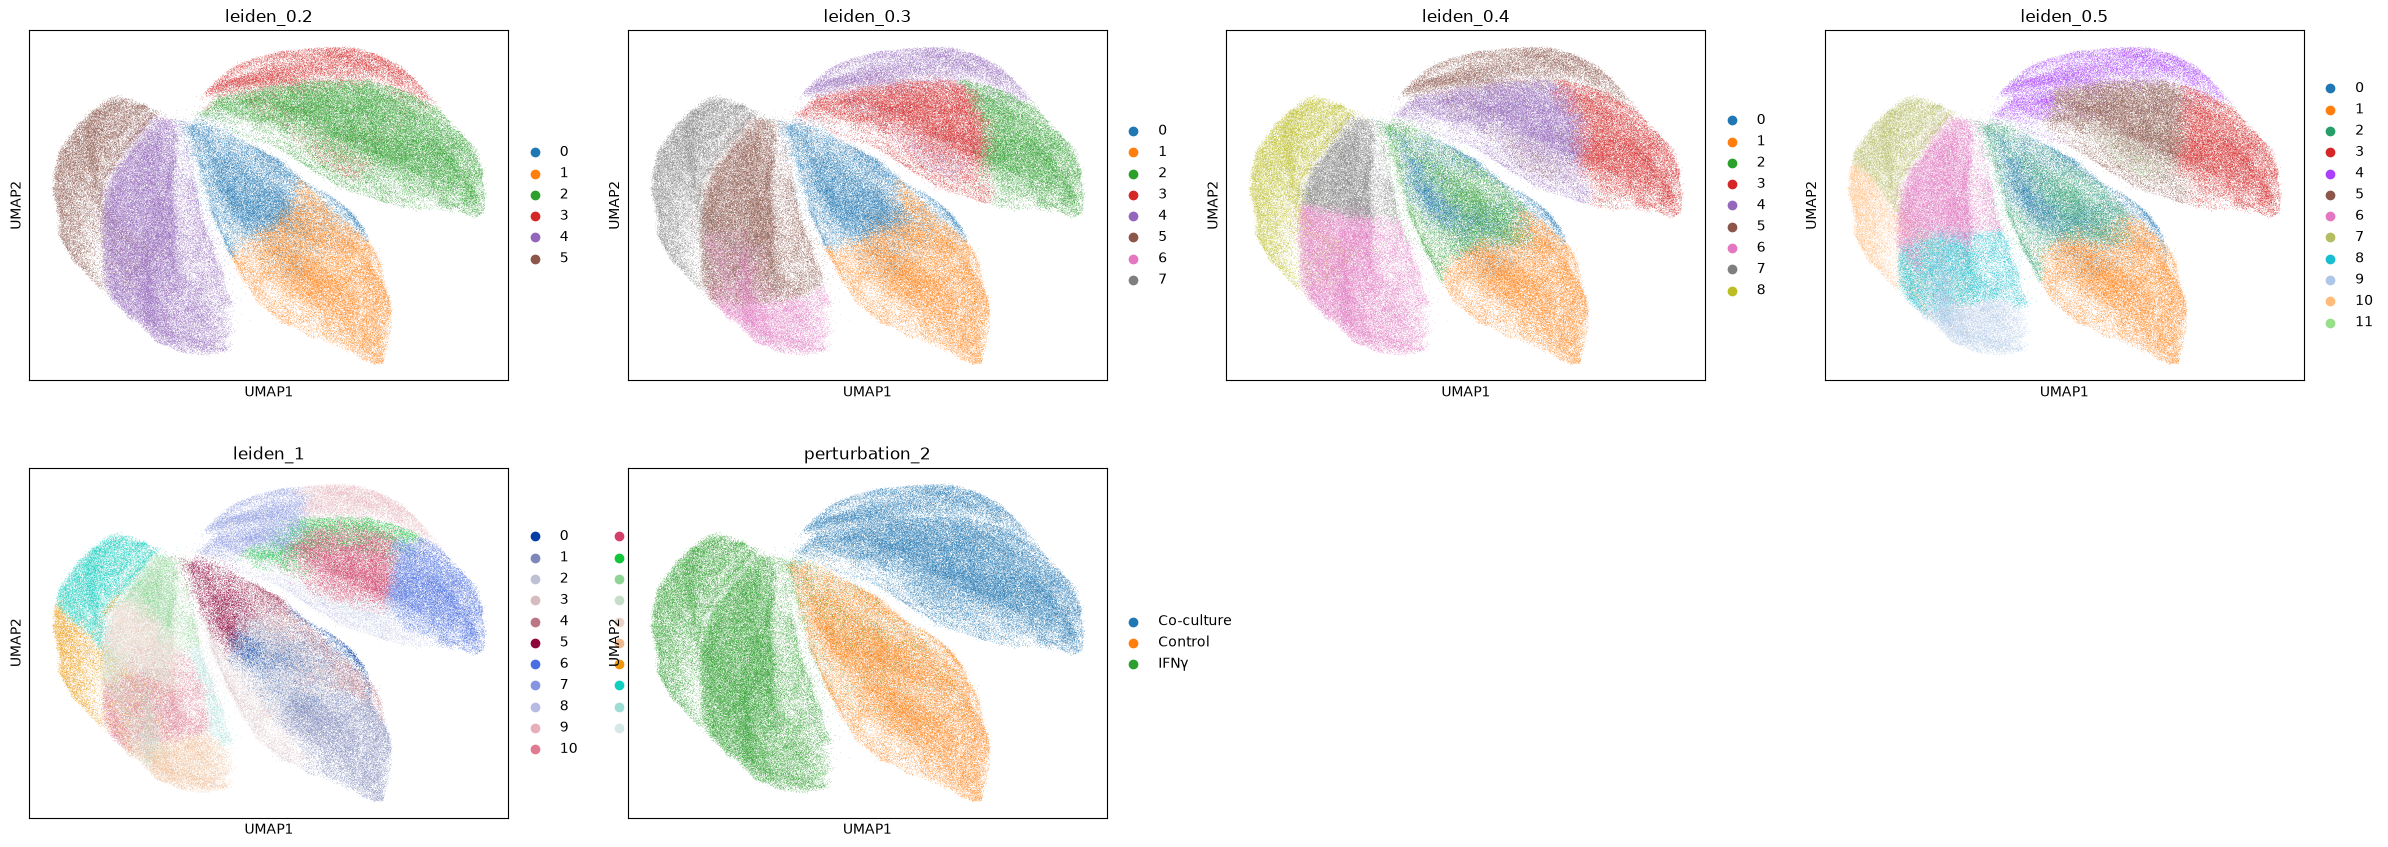

In [9]:
sc.pl.umap(
    adata,
    color=[f"leiden_{res}" for res in [0.2, 0.3, 0.4, 0.5, 1]]+["perturbation_2"]
)

In [10]:
from sklearn.cluster import KMeans

In [16]:
for n_clusters in range(2, 5):
    kmeans = KMeans(n_clusters=n_clusters)
    adata.obs[f"kmeans_{n_clusters}"] = kmeans.fit_predict(adata.obsm["X_pca"][:,1:])


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


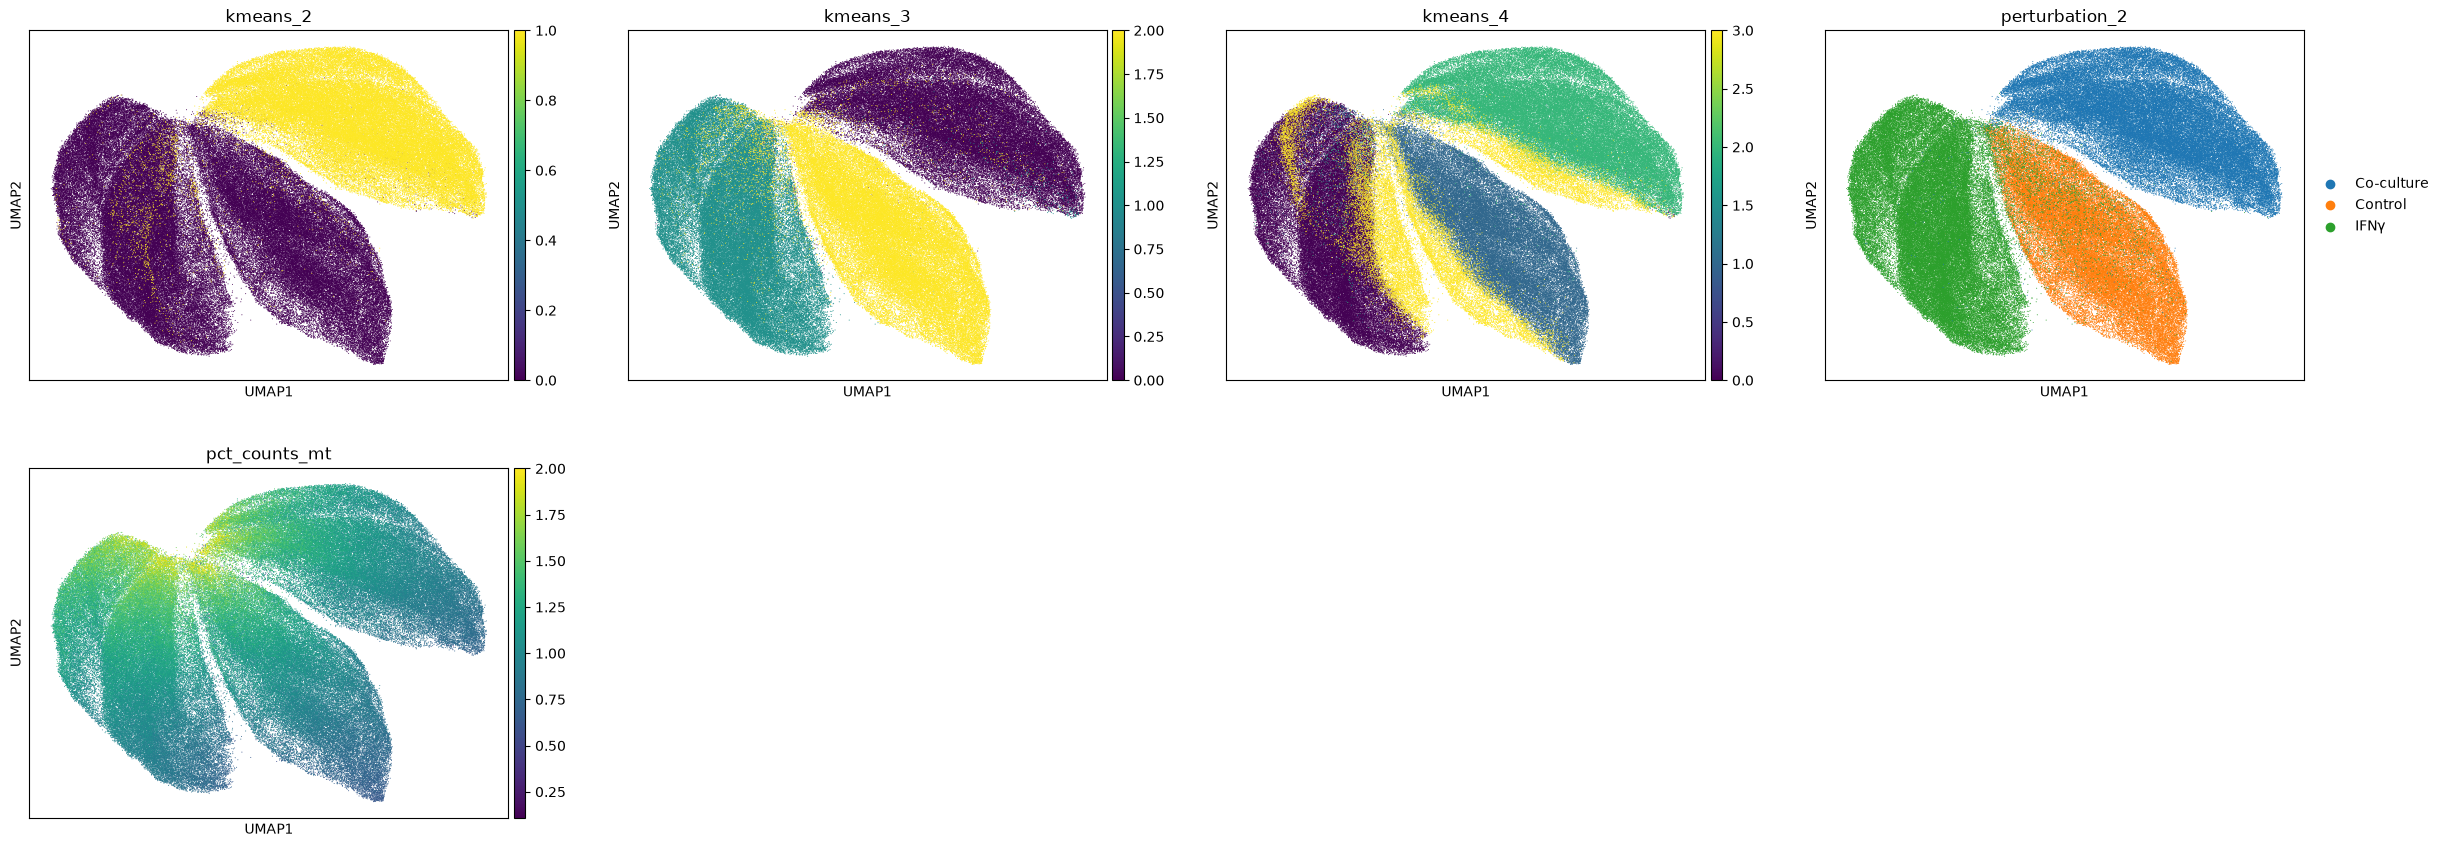

In [17]:
sc.pl.umap(
    adata,
    color=[f"kmeans_{n_clusters}" for n_clusters in range(2, 5)]+["perturbation", "pct_counts_mt"],
    size=2
)

In [13]:
adata.write_h5ad(data_dir/"clustered_data.h5ad")

In [20]:

n_pert = 50
adata.obs["perturbed_gene"] = adata.obs["perturbation"].map(lambda x: x.split("_")[0] if isinstance(x, str) else x)
counts_per_perturbation = adata.obs["perturbed_gene"].value_counts()
target_genes = counts_per_perturbation.sort_values(ascending=False).index[:n_pert]

In [40]:
adata.obs["perturbation"] = adata.obs["perturbation"].astype(str)
adata.obs["kmeans_3"] = adata.obs["kmeans_3"].astype(str)
adata.obs["perturbed_gene"] = adata.obs["perturbation"].map(lambda x: x.split("_")[0] if isinstance(x, str) else x).astype(str)


In [41]:
adata

AnnData object with n_obs × n_vars = 212679 × 14097
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'NO_SITE', 'ONE_NON-GENE_SITE', 'perturbation', 'perturbation_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_1', 'kmeans_2', 'kmeans_3', 'kmeans_4', 'perturbed_gene'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'pca', 'perturbation_2_colors', 'neighbors', 'umap', 'leiden_0.2', 'leiden_0.3', 

In [46]:
sc.pl.dotplot(adata,
    var_names=adata.obs["perturbed_gene"].unique().to_numpy(),
    groupby="kmeans_3",
    expression_cutoff = 0.0
    )

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


TypeError: '<' not supported between instances of 'float' and 'str'